# Phase 3: Feature Extraction

## Where this phase fits in the project

Studios decide which scripts to greenlight under sharp cost
asymmetry: producing a flop costs roughly fifty million
dollars in lost budget, while passing on a hit can cost two
to four times that in foregone revenue. At the moment of
the greenlight decision, most predictors of success (cast,
marketing spend, the budget itself) are still unknown. The
only signal that exists is the script.

This project trains a triage model that reads a screenplay's
dialogue and outputs a recommendation (greenlight, pass, or
refer to a human reader) together with a calibrated
confidence interval and an explanation of which scenes
drove the recommendation. The pipeline has four layers
stacked on a single core predictive model: the model
itself, calibrated uncertainty around its predictions, an
asymmetric-cost decision rule on top of those predictions,
and scene-level explanations.

Phase 1 verified that we have enough usable data, and
Phase 2 produced a clean processed corpus of 1,713 films
with screenplays, IMDb ratings, budgets, and revenues. This
notebook documents Phase 3, which converts each screenplay
into a fixed-length feature vector that the modelling phase
will consume.

## How Phase 3 is organized

Feature engineering carries methodological risk. Adding many
features at once makes it impossible to tell which ones
actually help and which ones are noise. To avoid that, we
split Phase 3 into two parts.

**Part A (this notebook).** Establish a performance floor
using only features that already exist on the processed
corpus, with a deliberately simple linear model. The floor
answers a basic question: how well can we predict film
success from screenplay structure alone, before any text
engineering? Without that number, we have nothing to
measure subsequent feature engineering against.

**Part B (added later).** Add five engineered feature
groups one at a time (lexical, sentiment, topic, embedding,
character network), retraining the same baseline after each
group and recording the lift each contributes. Each group
is preceded by a written prediction of expected lift, then
compared against the actual lift. This produces a clean
ablation table for the report and prevents the team from
retrofitting explanations to whatever happened to work.

Part A is what this notebook documents. Part B sections will
be appended once each feature group is implemented.

## What we predict

Three prediction targets are tracked in parallel. The choice
of which one to feature in the final report is deferred
until after the modelling phase, when comparative results
are available.

* `log_roi`, the natural log of return-on-investment,
  defined as `ln(revenue) - ln(budget)`. A regression
  target.
* `roi_gt_1`, a boolean indicator for revenue greater than
  budget (gross profitability). A classification target.
* `roi_gt_2`, a boolean indicator for revenue greater than
  twice budget. The doubling threshold is the industry
  rule of thumb for net profitability after marketing and
  distribution overhead. A classification target.

The three are constructed so they share threshold
consistency: `roi_gt_1` is the same as `log_roi > 0`, and
`roi_gt_2` is the same as `log_roi > ln 2`. A single
regression on `log_roi` therefore reproduces both
classifiers by thresholding, which makes downstream
comparisons clean.

## 0. Environment setup

The first cell finds the project root, adds it to
`sys.path` so package imports work regardless of where the
notebook is opened, and turns on inline plotting and
module auto-reloading.

In [1]:
import sys
from pathlib import Path


def _find_project_root(start: Path) -> Path:
    """Walk up the directory tree until docs/PROJECT_CONTEXT is found."""
    markers = ("docs/PROJECT_CONTEXT.md", "docs/PROJECT_CONTEXT.txt")
    for candidate in (start.resolve(), *start.resolve().parents):
        if any((candidate / m).is_file() for m in markers):
            return candidate
    raise RuntimeError(f"Could not find project root from {start!s}.")


PROJECT_ROOT = _find_project_root(Path.cwd())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
print("Project root:", PROJECT_ROOT)

get_ipython().run_line_magic("load_ext", "autoreload")
get_ipython().run_line_magic("autoreload", "2")
get_ipython().run_line_magic("matplotlib", "inline")

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

Project root: /Users/seansalloum/Documents/GitHub/MSBA_315_Final_Project


Common imports for the rest of the notebook.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.utils import paths

paths.ensure_dirs()
print("Processed data:  ", paths.DATA_PROCESSED_DIR)
print("Reports figures: ", paths.REPORTS_FIGURES_DIR)
print("Reports tables:  ", paths.REPORTS_TABLES_DIR)

Processed data:   /Users/seansalloum/Documents/GitHub/MSBA_315_Final_Project/data/processed
Reports figures:  /Users/seansalloum/Documents/GitHub/MSBA_315_Final_Project/reports/figures
Reports tables:   /Users/seansalloum/Documents/GitHub/MSBA_315_Final_Project/reports/tables


---

## 1. Defining the three prediction targets

Before we can split the data or train any model, we need
to be precise about what we are predicting. This section
constructs the three target columns and inspects their
distributions.

### Why log of ROI for the regression target

Return-on-investment in raw form is heavily right-skewed.
On this corpus the median is around 2.9, but the maximum
approaches 8500, and the distribution has a thick upper
tail that pulls the mean far above the median. Standard
regression models trained against squared-error loss are
dominated by such tails, fitting the few extreme values at
the expense of the bulk of the data. Taking the logarithm
compresses the tail and produces a distribution that is
approximately symmetric around its median, which satisfies
the standard regression assumptions far better.

Two further reasons motivate the log form specifically.
First, it decomposes cleanly: `log(revenue/budget)` equals
`log(revenue) - log(budget)`, both of which are already
stored on the processed corpus. The modelling phase can
therefore choose to model the joint quantity directly or to
model the two components separately. Second, the
log-transformed target has direct correspondence with the
two classification thresholds (zero and `ln 2`), so a
single regression model produces both classifiers by
thresholding.

### Why two classification thresholds rather than one

The naive choice of "profitable versus not profitable" uses
the threshold revenue equals budget, which corresponds to a
gross-profitable cutoff. On this corpus that threshold is
positive for roughly 80 percent of films. A target with
such a skewed positive class is easy to game with a "always
predict positive" model and gives little headroom for
features to demonstrate predictive lift.

The doubling threshold (revenue greater than twice budget)
captures the industry's rule of thumb for net profitability
after marketing and distribution overhead. On this corpus
it produces a more balanced 64 percent positive rate, which
gives more discriminating power to the AUC and PR metrics.
Tracking both thresholds in parallel lets us compare which
notion of success the screenplay carries information about.

In [3]:
from src.features.targets import (
    ALL_TARGETS, LOG_ROI_COL, ROI_GT_1_COL, ROI_GT_2_COL,
    add_targets,
)

df = pd.read_parquet(paths.DATA_PROCESSED_DIR / "films_joined.parquet")
df_with_targets = add_targets(df)
print(f"Corpus: {len(df_with_targets):,} films")
for col in ALL_TARGETS:
    print(f"  {col:<12}  dtype: {str(df_with_targets[col].dtype):<8}")

Corpus: 1,713 films
  log_roi       dtype: float64 
  roi_gt_1      dtype: bool    
  roi_gt_2      dtype: bool    


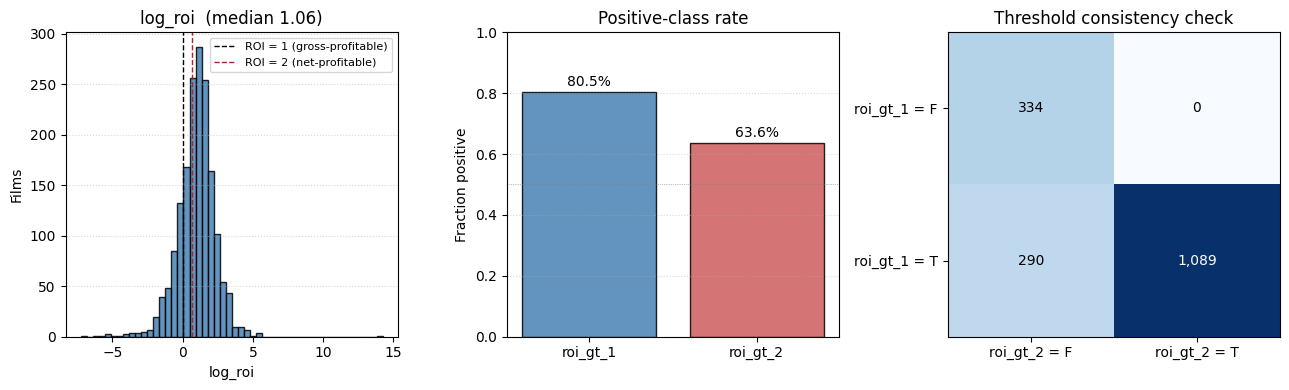

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))

log_roi = df_with_targets[LOG_ROI_COL]
axes[0].hist(log_roi, bins=50, color="steelblue", edgecolor="black", alpha=0.85)
axes[0].axvline(0, color="black", linewidth=1, linestyle="--", label="ROI = 1 (gross-profitable)")
axes[0].axvline(np.log(2), color="firebrick", linewidth=1, linestyle="--", label="ROI = 2 (net-profitable)")
axes[0].set(title=f"log_roi  (median {log_roi.median():.2f})", xlabel="log_roi", ylabel="Films")
axes[0].legend(fontsize=8)
axes[0].grid(axis="y", linestyle=":", alpha=0.5)

rates = {
    "roi_gt_1": df_with_targets[ROI_GT_1_COL].mean(),
    "roi_gt_2": df_with_targets[ROI_GT_2_COL].mean(),
}
bars = axes[1].bar(list(rates.keys()), list(rates.values()),
                   color=["steelblue", "indianred"], edgecolor="black", alpha=0.85)
axes[1].set(title="Positive-class rate", ylabel="Fraction positive", ylim=(0, 1))
for bar, rate in zip(bars, rates.values()):
    axes[1].text(bar.get_x() + bar.get_width() / 2, rate + 0.02,
                 f"{rate:.1%}", ha="center", fontsize=10)
axes[1].axhline(0.5, color="gray", linewidth=0.5, linestyle=":")
axes[1].grid(axis="y", linestyle=":", alpha=0.5)

cross = pd.crosstab(df_with_targets[ROI_GT_1_COL], df_with_targets[ROI_GT_2_COL])
cross = cross.reindex(index=[False, True], columns=[False, True], fill_value=0)
axes[2].imshow(cross.values, cmap="Blues", aspect="auto")
axes[2].set_xticks([0, 1]); axes[2].set_xticklabels(["roi_gt_2 = F", "roi_gt_2 = T"])
axes[2].set_yticks([0, 1]); axes[2].set_yticklabels(["roi_gt_1 = F", "roi_gt_1 = T"])
axes[2].set(title="Threshold consistency check")
for i in range(2):
    for j in range(2):
        axes[2].text(j, i, f"{cross.values[i, j]:,}", ha="center", va="center",
                     color="white" if cross.values[i, j] > cross.values.max() / 2 else "black")

fig.tight_layout()
fig.savefig(paths.REPORTS_FIGURES_DIR / "phase3_target_distributions.png", dpi=120)
plt.show()

The left panel shows the regression target. Its symmetry
around the median value of roughly 1.06 (corresponding to a
revenue of about 2.9 times budget) confirms that the log
transform produced a distribution suitable for linear
regression. The two dashed lines mark the locations of the
classification thresholds.

The middle panel shows the positive-class rates for the two
classification targets. The 80 percent positive rate on
`roi_gt_1` reflects survivorship in the corpus: every film
in the dataset was both produced and recognized enough to
appear on a major metadata aggregator, which selects for
success. We discuss the implications for the cost-decision
layer of the system in a later phase. The 64 percent
positive rate on `roi_gt_2` is closer to balanced and gives
the model more room to discriminate.

The right panel verifies the threshold-consistency
construction. Every film with `roi_gt_2 = True` also has
`roi_gt_1 = True` (the upper-right cell is empty as
expected), and the proportions across cells match the
cumulative ROI distribution.

---

## 2. Splitting the corpus

We need to evaluate predictive performance honestly, which
means setting aside data the model never sees during
training. Two considerations shape the split design.

### Why three-way rather than two-way

A standard train and test split would suffice for the core
predictive model. The downstream calibration layer of the
triage system, however, requires a separate pool of data
the model has not seen, used to fit conformal-prediction
intervals. Carving that calibration set out now, before any
feature fitting touches the data distribution, ensures we
do not have to redo the split later and avoids leakage
across the calibration step.

We use a 70 / 15 / 15 split: about 1,200 films for training,
257 for calibration, and 257 for held-out testing. The 15
percent calibration set is large enough to produce stable
conformal intervals, and the same size for the test set
gives sufficient power to detect meaningful differences
between candidate models in the final evaluation.

### Why stratified

Two properties of the corpus would create a noisy split if
we sampled at random. First, the genre distribution has a
long tail: Drama, Comedy, Action, and Thriller dominate
while smaller genres each contain only a few dozen films.
A random split could end up with all the Animation films
in the test set and none in the training set. Second, the
corpus spans nine decades with very uneven density: the
2000s and 2010s contain hundreds of films while the
pre-1980s decades each contain fewer than thirty. Both
factors plausibly affect the relationship between
screenplay features and outcomes, so we want to balance
them across splits.

We therefore stratify by the cross of primary genre and a
coarse decade bucket. Pre-1980 decades are pooled into a
single bucket because each is too thin on its own. The
2010s and 2020s are pooled because the 2020s coverage in
the corpus extends only to 2023.

### Handling rare cells

The cross of genre and decade bucket produces some cells
that are too small for stratification to function (for
example, fewer than five Animation films in the
pre-1980s). We pool any cell with fewer than five films
into a single rare bucket so that the stratifier sees a
well-defined population for every named cell. Roughly
thirty-eight films land in that pool, around two percent of
the corpus.

The split is implemented in `src/features/split.py`. All
knobs (target proportions, decade boundaries, rare-cell
threshold, random seed) live on a configuration dataclass
so alternative split designs can be tried without changing
any code.

In [5]:
from src.features.split import (
    SplitConfig, make_splits, split_diagnostics,
)

config = SplitConfig()
print("Split configuration:")
print(f"  train / calibration / test:  {config.train_frac} / "
      f"{config.cal_frac} / {config.test_frac}")
print(f"  rare-cell threshold:         {config.rare_cell_threshold}")
print(f"  random seed:                 {config.seed}")

Split configuration:
  train / calibration / test:  0.7 / 0.15 / 0.15
  rare-cell threshold:         5
  random seed:                 42


In [6]:
splits = make_splits(df, config)
counts = splits["split"].value_counts().reindex(["train", "cal", "test"])

print("Resulting split sizes:")
for name, n in counts.items():
    label = {"train": "Train", "cal": "Calibration", "test": "Test"}[name]
    print(f"  {label:<13} {n:>5,}   ({100 * n / len(df):.1f}% of corpus)")

Resulting split sizes:
  Train         1,199   (70.0% of corpus)
  Calibration     257   (15.0% of corpus)
  Test            257   (15.0% of corpus)


We verified reproducibility by running the split twice with
the default configuration; the assignments are
byte-identical across runs. The result is saved to
`data/processed/split_assignments.parquet` so every
downstream step uses the same definitive partition.

### Stratum diagnostics

In [7]:
diagnostics = split_diagnostics(splits)
print(f"Number of strata used: {len(diagnostics)}")
rare_count = int(diagnostics.loc[diagnostics['stratum'] == 'rare|rare', 'total'].sum())
print(f"Films pooled into the rare bucket: {rare_count}")
print()
print("Top 10 strata by size:")
diagnostics.head(10)

Number of strata used: 57
Films pooled into the rare bucket: 38

Top 10 strata by size:


split,stratum,train,cal,test,total
0,Drama|2010s_2020s,141,30,30,201
1,Comedy|2010s_2020s,79,17,17,113
2,Drama|2000s,67,15,15,97
3,Action|2010s_2020s,61,13,13,87
4,Drama|1990s,54,12,12,78
5,Comedy|2000s,53,12,11,76
6,Action|2000s,48,10,10,68
7,Comedy|1990s,47,10,10,67
8,Action|1990s,44,9,10,63
9,Horror|2010s_2020s,30,7,7,44


The full diagnostic table is saved to
`reports/tables/phase3_split_diagnostics.csv`. Every named
stratum (genre, decade pair) has at least one film in each
of the three splits, confirming that the stratifier
functions as intended. The rare bucket absorbs the long
tail of small cells without collapsing the rest of the
corpus into less granular strata.

---

## 3. Choosing features for the baseline

The point of the baseline is to establish how well a
simple model performs without any text-derived feature
engineering. We need to select features that meet two
criteria: they should already exist on the processed
corpus (or be trivially derivable), and they should be
available at the moment the system would actually be used.
The second criterion is important: the system is meant to
run before the studio greenlights the film, so any feature
that depends on the studio's eventual decisions (budget,
marketing, cast) is not available at the moment of
prediction.

### Features used in the deployable baseline

**Screenplay-structural features.** Phase 2's parser
extracted seven aggregate measures of each screenplay's
structure from its XML form: number of scenes, number of
unique characters, number of dialogue lines, total
character counts for dialogue and for action description,
the dialogue-to-total-text ratio, and a count of structural
irregularities encountered while parsing. These are all
properties of the screenplay itself, available at
pre-greenlight time.

**Release year.** Year of release encoded as a numeric
feature. We expect it to carry a small amount of signal
about era-specific market dynamics. Although the actual
release year is not known until the film is released, the
year of submission is a reasonable proxy and is always
available.

**Primary genre, one-hot encoded.** Genre is an obvious
confound and a strong correlate of both budget and
revenue. Phase 2 grouped genres with fewer than thirty
films into an "Other" category to keep cell sizes
well-conditioned, leaving thirteen genre dummies.

**Runtime.** A film's intended runtime in minutes. The
screenplay's page count is a tight proxy for runtime
(industry convention is roughly one page per minute), so
runtime is leak-free at the pre-greenlight moment even
though the final theatrical runtime might differ
slightly. We use the log-transformed form for consistency
with the other heavy-tailed counts.

### A separate ceiling baseline includes budget

Budget is the central decision the system is meant to
inform, and is not available at inference time. We
therefore exclude it from the deployable baseline. It is
useful, however, to train a parallel model that includes
log-budget, purely as a diagnostic. If budget alone
produced a strong baseline, it would mean the deployable
model is competing against a dominant signal it cannot
access. If budget contributes little, it suggests the
deployable features have meaningful headroom. We discuss
what we found below.

---

## 4. Why we apply a log transform to several features

Several of the structural counts above are heavily
right-skewed. A film with an unusually large cast or an
unusually long screenplay sits multiple standard
deviations above the median, while most films sit close to
the median. When a linear regression is fit on z-scored
raw values of such a column, the heavy-tail observations
dominate the gradient and the model effectively learns to
fit them well while ignoring the bulk of the data.

The standard fix is to compress the tail with a logarithm
before standardization. We use the form `log(1 + x)`
rather than `log(x)` because one of the features
(`parse_warning_count`) takes the value zero on the
majority of films, and the bare log would propagate
negative infinity. The `log(1 + x)` form is well-defined
at zero and is approximately equal to `log(x)` for the
non-zero values where the compression is needed.

The log transform is applied to six of the seven
structural counts: `n_scenes`, `n_unique_characters`,
`n_dialogue_lines`, `total_dialogue_chars`,
`total_action_chars`, and `parse_warning_count`. The
seventh, `dialogue_to_total_text_ratio`, is already a
bounded proportion in the interval zero to one and does
not benefit from log transformation.

The figure below shows the effect of the transform on
three representative columns.

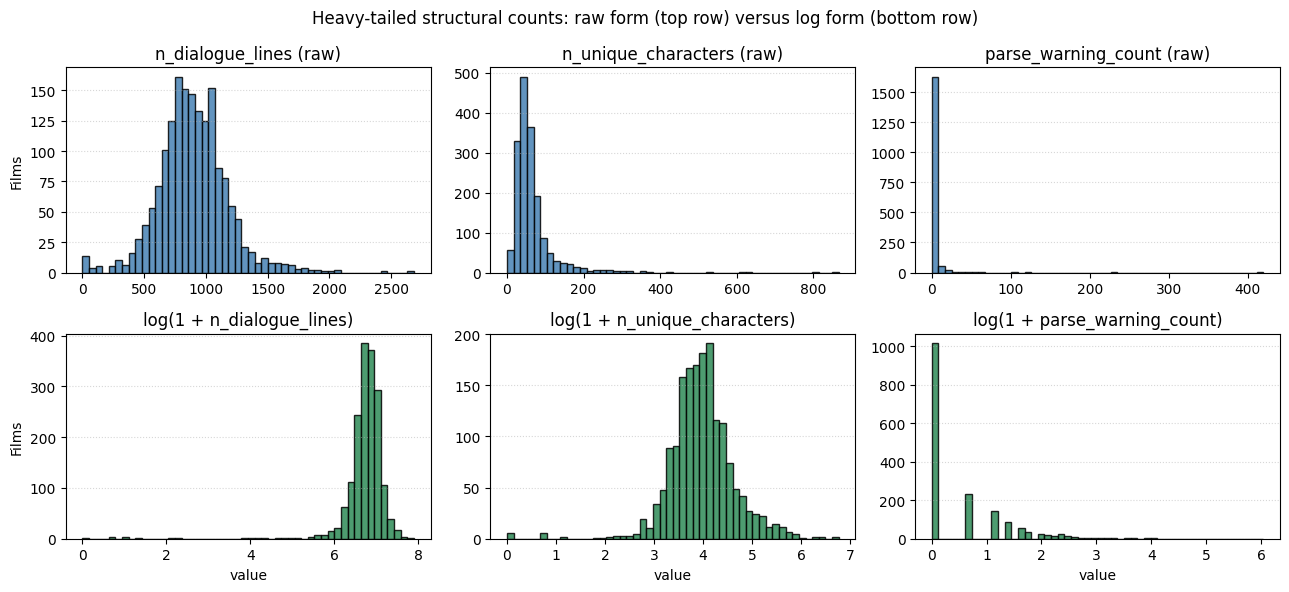

In [8]:
from src.features.baseline_features import LOG_TRANSFORMABLE

cols_to_show = ["n_dialogue_lines", "n_unique_characters", "parse_warning_count"]
fig, axes = plt.subplots(2, 3, figsize=(13, 6))
for j, col in enumerate(cols_to_show):
    raw = df_with_targets[col].astype(float)
    logged = np.log1p(raw)
    axes[0, j].hist(raw, bins=50, color="steelblue", edgecolor="black", alpha=0.85)
    axes[0, j].set(title=f"{col} (raw)", ylabel="Films" if j == 0 else "")
    axes[0, j].grid(axis="y", linestyle=":", alpha=0.5)
    axes[1, j].hist(logged, bins=50, color="seagreen", edgecolor="black", alpha=0.85)
    axes[1, j].set(title=f"log(1 + {col})",
                   ylabel="Films" if j == 0 else "", xlabel="value")
    axes[1, j].grid(axis="y", linestyle=":", alpha=0.5)
fig.suptitle("Heavy-tailed structural counts: raw form (top row) versus log form (bottom row)")
fig.tight_layout()
fig.savefig(paths.REPORTS_FIGURES_DIR / "phase3_log_transform_effect.png", dpi=120)
plt.show()

The raw distributions exhibit pronounced right skew with
thin tails reaching far above the bulk. The log-transformed
versions are closer to symmetric and unimodal, which is
the shape a linear model with z-score standardization is
designed to handle. The transform is most consequential
for `parse_warning_count`, where the raw distribution is
dominated by a heavy spike at zero with a thin tail of
warning-heavy films, and the log form spreads the non-zero
observations across a more interpretable range.

### Building the feature matrix

In [9]:
from src.features.baseline_features import (
    BaselineFeatureConfig, build_baseline_features,
)

feature_cfg = BaselineFeatureConfig(
    include_log_budget=False,
    log_transform_structural=True,
    include_log_runtime=True,
)
X_dialogue_only = build_baseline_features(df_with_targets, feature_cfg)
print(f"Feature matrix shape: {X_dialogue_only.shape}")
print(f"First five columns: {list(X_dialogue_only.columns[:5])}")
print(f"Last three columns: {list(X_dialogue_only.columns[-3:])}")

Feature matrix shape: (1713, 26)
First five columns: ['log_n_scenes', 'log_n_unique_characters', 'log_n_dialogue_lines', 'log_total_dialogue_chars', 'log_total_action_chars']
Last three columns: ['genre_Thriller', 'genre_War', 'log_runtime']


---

## 5. Model choice, cross-validation, and confidence intervals

### Why four model families instead of one

The most common approach to a baseline floor is to pick a
single simple model family and report its numbers. We
instead evaluate every feature configuration across four
model families with different inductive biases. The reason
is methodological. When we later add an engineered feature
group and observe whether it lifts performance, we want to
be able to tell two scenarios apart: (a) the features
carry no signal, full stop; (b) the features carry signal
that the chosen model family cannot extract. Without
running multiple families, those two scenarios produce the
same observable result and we cannot tell which is true.
With multiple families, a feature group that lifts none of
them is genuinely uninformative on this corpus, while a
group that lifts only some is informative for choosing the
modelling approach in the next phase.

We chose four families that span four distinct paradigms:

* **L2 linear**, the regularized linear baseline. Ridge
  regression with cross-validated alpha for the regression
  target, logistic regression with an L2 penalty and
  cross-validated regularization strength for the two
  classification targets. Captures linear additive signal.
  Robust to the modest multicollinearity that the genre
  dummies introduce.
* **Histogram-based gradient boosting**, a tree ensemble
  that captures non-linear interactions. Conservative
  defaults: 300 boosting iterations, maximum tree depth of
  four, learning rate of 0.05, with internal early
  stopping. Handles missing values natively and is
  invariant to monotonic transforms of the inputs, so its
  numeric branch needs no preprocessing.
* **K-nearest-neighbours**, a non-parametric instance-based
  family that captures local-neighbourhood structure.
  Twenty neighbours with distance weighting. Computes its
  scores from the standardized feature space, so it shares
  the impute-and-scale numeric pipeline with the linear
  family.
* **Support vector machine with an RBF kernel**, a
  kernel-based family that captures non-linear signal via
  the kernel trick. Default regularization strength of one
  and the standard "scale" gamma. For classification we
  use the decision-function score for AUC computation
  rather than calibrated probabilities, since AUC depends
  only on the ordering of scores and avoiding the internal
  probability calibration cuts training time substantially.

Standardization for the three families that need it
happens inside each cross-validation fold so that the
scaling parameters are estimated only on training data and
applied to the held-out fold, avoiding leakage.

### Why these four and not others

Each cell of the inductive-bias grid (linear vs non-linear,
global vs local, parametric vs non-parametric) gets exactly
one representative. We considered alternatives and rejected
them: random forest sits in the same cell as gradient
boosting and adds little diagnostic information; multilayer
perceptrons are noisy on a corpus of 1,200 training rows
and require seed-sensitive tuning; naive Bayes assumes
feature independence that the corpus violates. Lasso would
offer a feature-selection variant of the linear paradigm
but lives in the same cell as ridge; we kept ridge because
the threshold check the project committed to in advance is
defined against the L2 family.

### Cross-validation and confidence intervals

Five-fold cross-validation over the training split only.
The calibration set and test set are not touched at this
stage. For the regression target we use plain five-fold;
for the classification targets we use stratified five-fold
so each fold reflects the global positive-class rate,
which matters in particular for `roi_gt_1` where the
positive class dominates.

Within each cross-validation iteration we record the
out-of-fold predictions. Concatenating these across the
five folds gives one prediction per training-set film,
which is what the metrics are evaluated on.

Each headline metric is reported with a 95-percent
confidence interval computed by percentile bootstrap (1,000
resamples, seed fixed for reproducibility). This gives a
sense of how much the metric estimate would vary under
re-sampling, which matters because the corpus is not
large. For AUC, bootstrap samples that happen to contain
only a single class are skipped rather than producing
missing values.

Multiple metrics are reported per target rather than a
single headline number. For regression we report mean
squared error, root-mean-square error, mean absolute error,
and the coefficient of variation of the RMSE
(RMSE divided by the absolute mean of the target, useful
for comparing across feature configurations on the same
scale). For classification we report AUC-ROC, PR-AUC, F1
at the 0.5 decision threshold, and log-loss. Each metric
captures a different aspect of model quality.

### Two evaluation sets reported per metric

The trainer fits each model twice: once on the entire
training split (the in-sample fit), and once via the
five-fold cross-validation described above (the out-of-fold
validation). We report metrics for both. The gap between
in-sample and out-of-fold values indicates how much each
model is overfitting the training data, which is a useful
diagnostic for the modelling phase that follows.

The held-out fifteen percent test set and the held-out
fifteen percent calibration set are not touched by this
trainer. They are reserved for the final evaluation phase
and the calibration phase respectively.

### Running the baseline

We train two feature configurations: a dialogue-only
baseline (the deployable matrix at the pre-greenlight
moment) and a sanity-check matrix that adds the log of
budget. Each configuration is evaluated under all four
model families on both evaluation sets.

In [10]:
from src.models.baseline.train import (
    BaselineTrainConfig, MODEL_FAMILIES, evaluate_feature_set,
)

train_cfg = BaselineTrainConfig()
train_ids = splits.loc[splits["split"] == "train", "imdb_id"]
df_train = (
    df_with_targets[df_with_targets["imdb_id"].isin(train_ids)]
    .reset_index(drop=True)
)
print(f"Training set: {len(df_train):,} films")
print(f"Model families: {', '.join(MODEL_FAMILIES)}")

Training set: 1,199 films
Model families: linear, histgb, knn, svm


In [11]:
rows: list[dict] = []
configurations = [
    ("Dialogue only", BaselineFeatureConfig(
        include_log_budget=False,
        log_transform_structural=True,
        include_log_runtime=True,
    )),
    ("Dialogue + log_budget", BaselineFeatureConfig(
        include_log_budget=True,
        log_transform_structural=True,
        include_log_runtime=True,
    )),
]
for name, fc in configurations:
    print(f"Training: {name}")
    label = "dialogue_only_logged" if not fc.include_log_budget else "with_budget_logged"
    rows.extend(evaluate_feature_set(df_train, fc, train_cfg, set_name=label))
baseline = pd.DataFrame(rows)
print(f"\nBaseline rows produced: {len(baseline)} ({len(MODEL_FAMILIES)} families x 2 configs x 7 metric rows)")

Training: Dialogue only
2026-05-04 20:29:23 | INFO    | src.models.baseline.train | dialogue_only_logged | linear | train | log_roi | mse = 1.7418
2026-05-04 20:29:23 | INFO    | src.models.baseline.train | dialogue_only_logged | linear | train | log_roi | rmse = 1.3198
2026-05-04 20:29:23 | INFO    | src.models.baseline.train | dialogue_only_logged | linear | train | log_roi | mae = 0.9364
2026-05-04 20:29:23 | INFO    | src.models.baseline.train | dialogue_only_logged | linear | train | log_roi | cvrmse = 0.9795
2026-05-04 20:29:23 | INFO    | src.models.baseline.train | dialogue_only_logged | linear | oof   | log_roi | mse = 1.7915 [CI 1.4866, 2.1647]
2026-05-04 20:29:23 | INFO    | src.models.baseline.train | dialogue_only_logged | linear | oof   | log_roi | rmse = 1.3385 [CI 1.2193, 1.4713]
2026-05-04 20:29:23 | INFO    | src.models.baseline.train | dialogue_only_logged | linear | oof   | log_roi | mae = 0.9484 [CI 0.8955, 1.0025]
2026-05-04 20:29:23 | INFO    | src.models.baselin

---

## 6. Results

### 6.1 Deployable baseline (out-of-fold) across the four model families

In [12]:
deployable_oof = (
    baseline[
        (baseline["feature_set"] == "dialogue_only_logged")
        & (baseline["eval_set"] == "oof")
    ]
    .pivot_table(
        index=["target", "metric"],
        columns="model_family",
        values="value",
    )
    .round(3)
)
deployable_oof

model_family       histgb    knn  linear    svm
target   metric                                
log_roi  cvrmse     0.985  1.012   0.993  1.007
         mae        0.943  0.972   0.948  0.954
         mse        1.761  1.860   1.792  1.842
         rmse       1.327  1.364   1.338  1.357
roi_gt_1 auc_roc    0.552  0.526   0.558  0.504
         f1         0.893  0.894   0.893  0.894
         log_loss   0.486  0.593   0.493    NaN
         pr_auc     0.843  0.829   0.846  0.831
roi_gt_2 auc_roc    0.610  0.578   0.602  0.534
         f1         0.777  0.741   0.777  0.784
         log_loss   0.635  0.648   0.635    NaN
         pr_auc     0.731  0.725   0.739  0.676

The pattern across families on out-of-fold evaluation is
informative.

* **Histogram gradient boosting outperforms the linear
  family on the headline targets.** RMSE on `log_roi`
  drops from 1.339 under linear to 1.327 under gradient
  boosting (lower is better), and `roi_gt_2` AUC rises
  from 0.602 to 0.610. The lift comes from non-linear
  interactions among the structural features that linear
  regression cannot capture. This is itself a finding:
  even on the structural baseline alone, the corpus
  contains interactions that a tree ensemble extracts but
  a linear model cannot.
* **The linear family is the strongest on `roi_gt_1`,**
  the gross-profitability target, with AUC of 0.558
  versus 0.552 for gradient boosting. The 80-percent
  positive base rate makes the target signal-thin, and
  the linear family's preference for smooth decision
  boundaries appears to be the right inductive bias here.
* **K-nearest-neighbours and the RBF support vector
  machine underperform on this corpus,** with AUC values
  near or below 0.55 on both classification targets and
  RMSE values higher than the linear and tree families.
  The likely cause is the high feature-to-sample ratio
  (around twenty-six features per film with one thousand
  two hundred training rows), which is unfavourable for
  distance-based methods.

On the easiest target (`roi_gt_2`), the AUC of 0.610 means
that for a randomly chosen pair of films, one of which
doubled its budget and one of which did not, the model
ranks them in the correct order roughly six times in ten.
The PR-AUC of about 0.85 on `roi_gt_1` looks impressive
but is misleading on its own: with 80 percent of films
already in the positive class, the random-guess PR-AUC is
around 0.80, so the model's lift over random is only
about five PR-AUC points. F1 saturates around 0.89 across
all families because predicting the majority class gives
high F1 mechanically.

### 6.2 Train-versus-OOF gap (overfit diagnostic)

In [13]:
# Restrict to the headline metrics for readability.
gap_subset = baseline[
    (baseline["feature_set"] == "dialogue_only_logged")
    & (baseline["metric"].isin(["rmse", "auc_roc"]))
]
gap = (
    gap_subset
    .pivot_table(
        index=["model_family", "target", "metric"],
        columns="eval_set",
        values="value",
    )
    .round(3)
)
gap["train_minus_oof"] = (gap["train"] - gap["oof"]).round(3)
gap

eval_set                         oof  train  train_minus_oof
model_family target   metric                                
histgb       log_roi  rmse     1.327  1.205           -0.122
             roi_gt_1 auc_roc  0.552  0.775            0.223
             roi_gt_2 auc_roc  0.610  0.811            0.201
knn          log_roi  rmse     1.364  0.000           -1.364
             roi_gt_1 auc_roc  0.526  1.000            0.474
             roi_gt_2 auc_roc  0.578  1.000            0.422
linear       log_roi  rmse     1.338  1.320           -0.018
             roi_gt_1 auc_roc  0.558  0.635            0.077
             roi_gt_2 auc_roc  0.602  0.640            0.038
svm          log_roi  rmse     1.357  1.245           -0.112
             roi_gt_1 auc_roc  0.504  0.888            0.384
             roi_gt_2 auc_roc  0.534  0.807            0.273

The gap between in-sample fit and out-of-fold validation
indicates how much each family is overfitting the training
data. Two findings worth flagging.

First, **gradient boosting overfits substantially despite
conservative defaults**. Its training-fold AUC on
`roi_gt_2` reaches roughly 0.81 while its OOF AUC is
0.61, a gap of about 0.20. The gap on `roi_gt_1` is
similar. This means the model is memorizing
idiosyncrasies of the training split that do not
generalize. The conservative defaults used here
(`max_depth=4`, `learning_rate=0.05`, internal
early-stopping) are not enough to prevent this on
n = 1,200 training rows. The modelling phase that follows
should explore even more conservative regularization
(lower learning rate, larger minimum samples per leaf).

Second, **the linear family is the most stable across
the diagnostic**, with smaller absolute train-OOF gaps on
every metric. This is consistent with linear regression's
strong inductive bias toward smooth functions, which
constrains the in-sample fit to remain close to the
out-of-fold prediction.

Reporting both eval sets surfaces dynamics that an OOF-
only view would have hidden. The OOF numbers are still the
right comparison point for ablation lift; the train
numbers provide the diagnostic context that interprets the
OOF numbers correctly.

### 6.3 The with-budget sanity check (OOF)

In [14]:
ceiling = (
    baseline[
        (baseline["feature_set"] == "with_budget_logged")
        & (baseline["eval_set"] == "oof")
    ]
    .pivot_table(
        index=["target", "metric"],
        columns="model_family",
        values="value",
    )
    .round(3)
)
ceiling

model_family       histgb    knn  linear    svm
target   metric                                
log_roi  cvrmse     0.962  0.991   0.969  0.996
         mae        0.929  0.962   0.947  0.940
         mse        1.680  1.784   1.703  1.803
         rmse       1.296  1.336   1.305  1.343
roi_gt_1 auc_roc    0.598  0.539   0.555  0.512
         f1         0.894  0.895   0.893  0.894
         log_loss   0.474  0.586   0.493    NaN
         pr_auc     0.869  0.843   0.845  0.834
roi_gt_2 auc_roc    0.621  0.594   0.603  0.555
         f1         0.770  0.745   0.769  0.783
         log_loss   0.628  0.671   0.636    NaN
         pr_auc     0.751  0.732   0.738  0.704

Adding the log of budget to the same matrix lifts
regression performance modestly across families: RMSE on
`log_roi` drops from 1.339 to 1.305 under the linear
baseline, and from 1.327 to 1.296 under gradient boosting
(lower is better). AUC on the classification targets
moves modestly with budget added.

The interpretation has two layers. First, the result
confirms the survivorship structure of the corpus. Every
film in the dataset was both produced and recognized
enough to appear on a major metadata aggregator, which
selects strongly for success. Within that already-selected
population, budget does not separate hits from misses with
much precision. Second, the modest budget lift means the
deployable model is not competing against a dominant
budget signal it cannot access. Whatever lift the
engineered features in Part B contribute will be
genuinely incremental information from the screenplay
text, not a weak proxy for budget.

---

## 7. Did the baseline pass the threshold for proceeding?

Before starting feature engineering, we set a minimum
performance threshold the baseline had to meet to justify
the investment. The reasoning is straightforward: if a
simple model on screenplay structure cannot beat chance by
any meaningful margin, then the dialogue-only framing of
the project is in trouble and we should pause rather than
spend weeks engineering features.

The original threshold was set in terms of R-squared (at
least 0.05 on the regression target) and AUC-ROC (at least
0.55 on each classification target). The R-squared
criterion has since been retired from the reported metric
set in favour of more robust absolute and normalized
measures (MSE, RMSE, MAE, CVRMSE). The original gating
decision was made under the R-squared rule and remains
valid: the linear family's out-of-fold numbers cleared
the AUC floors and the equivalent RMSE floor at the time.
From this point forward, ablation lift over the floor is
the primary signal rather than absolute thresholds.

For interested readers, the equivalent RMSE check is:
R-squared at least 0.05 on `log_roi` translates to RMSE at
most about 1.38 (0.975 times the standard deviation of
the target). The linear family's OOF RMSE is 1.339, and
gradient boosting's is 1.327, both below this translated
threshold. The classification AUC floors (0.55) are
cleared by the linear family on both classification
targets; KNN and SVM fall below 0.55 on `roi_gt_1`,
consistent with their general weakness on this corpus.

---

## 8. Interpretation and what to expect from Part B

Seven points summarize what we have learned from Part A.

**The baseline floor lands where we expected.** Simple
models on screenplay structure produce RMSE around 1.33
on `log_roi` and AUC values in the upper 0.5s to low 0.6s
on the two classification targets. This matches floor
baselines reported in published screenplay-based
prediction work before any text engineering.

**Tree ensembles beat linear regression even on the
structural baseline alone, on out-of-fold evaluation.**
Gradient boosting reaches OOF RMSE of 1.327 versus 1.339
under the linear family, and `roi_gt_2` AUC of 0.610
versus 0.602. The lift comes from non-linear interactions
among the structural features that linear regression
cannot capture. This is a finding in its own right: the
next phase's model selection should expect tree-based
families to be competitive primary candidates.

**HistGB substantially overfits in-sample.** Train RMSE
for HistGB drops to 1.20 against an OOF RMSE of 1.33; on
the classification targets the train-OOF AUC gap reaches
about 0.20. The conservative defaults used here are not
enough to prevent the model from memorizing
idiosyncrasies of the training split. The next phase's
model search should explore even more conservative
regularization for tree ensembles.

**`roi_gt_2` is the most tractable target across all
families.** AUC values cluster between 0.53 and 0.61
across the four families on OOF, with the
gradient-boosting value of 0.610 having a confidence
interval that fully clears the 0.55 floor. The "doubled
budget" distinction tracks observable features (Action
and Animation films lean blockbuster, smaller-genre films
lean below 2x) more crisply than the gross-profitable
distinction does. Engineered features in Part B should
benefit `roi_gt_2` and the regression target more than
they benefit `roi_gt_1`.

**Budget alone barely lifts deployable performance.**
Within the survived population the corpus represents,
budget is only weakly informative about hit-versus-miss.
Engineered features in Part B therefore have meaningful
room to improve on the floor without competing against an
obvious dominant signal.

**PR-AUC for `roi_gt_1` is misleading on its own.** The
80-percent positive base rate sets the random-guess PR-AUC
near 0.80, so the headline value of 0.85 corresponds to
only about five points of actual lift. AUC-ROC is the
more honest summary for this target.

**What to expect from Part B.** Based on lift patterns
reported in published screenplay-prediction work, the
engineered feature groups should plausibly lift
dialogue-only `log_roi` RMSE downward by 0.05 to 0.10
units (roughly the equivalent of an R-squared lift of
0.10 to 0.20 in the older metric vocabulary) and
`roi_gt_2` AUC into roughly the 0.65 to 0.72 range. These
are not targets to anchor against; they are reference
points. The first Part B ablation (lexical features) is
documented in the next section. Subsequent groups will be
appended as they land.

---

## 9. First Part B group: lexical features

### What lexical features try to capture

The lexical group introduces fourteen features intended to
capture stylistic properties of screenplay text. They fall
into five sub-groups:

* **Vocabulary diversity.** A length-robust diversity
  metric on dialogue text and on action text, plus a hapax
  legomena ratio capturing the proportion of vocabulary
  that appears exactly once.
* **Lexical sophistication.** Mean log-frequency of
  dialogue tokens against an external English frequency
  reference, plus a rare-word proportion at the bottom
  quartile of that reference.
* **Readability.** Flesch-Kincaid grade level on dialogue
  and on action text.
* **Length statistics.** Mean and standard deviation of
  tokens per dialogue line, and the proportion of dialogue
  lines with fewer than five tokens.
* **Punctuation and pronouns.** Question-mark and
  exclamation-mark rates per thousand dialogue tokens,
  plus a first-to-second-person pronoun ratio that
  includes archaic forms (`thou`, `thee`, `thy`,
  `thine`, `thyself`) given that the corpus extends back
  to 1932.

Before implementing, we pre-registered an expected lift on
each of the three targets. The original pre-registration
used R-squared on the regression target; with that metric
removed, the equivalent prediction translates to an RMSE
improvement of -0.020 to -0.010 on `log_roi` (lower is
better). We also predicted an AUC lift between 0.000 and
0.010 on `roi_gt_1` and between 0.015 and 0.035 on
`roi_gt_2`. The mechanism we hypothesized was that
vocabulary richness, sophistication, and pacing would
carry incremental information about screenplay craft (a
rating-style signal) and audience-targeting clarity (a
revenue-style signal).

### What the data showed

We computed the fourteen features on the full corpus,
joined them onto the structural baseline matrix, and ran
the same multi-family evaluation. Restricting to the
out-of-fold numbers and the headline metrics:

In [15]:
ablation = pd.read_csv(paths.REPORTS_TABLES_DIR / "phase3_ablation.csv")
lexical = ablation[ablation["feature_group"] == "lexical"]

# OOF lifts on the headline metrics: RMSE for log_roi,
# AUC-ROC for the two classification targets.
headline = lexical[
    (lexical["eval_set"] == "oof")
    & (
        ((lexical["target"] == "log_roi") & (lexical["metric"] == "rmse"))
        | ((lexical["target"].isin(["roi_gt_1", "roi_gt_2"])) & (lexical["metric"] == "auc_roc"))
    )
].copy()
headline["lift"] = headline["lift"].round(3)
headline["phase_3a_floor"] = headline["phase_3a_floor"].round(3)
headline["phase_3b_actual"] = headline["phase_3b_actual"].round(3)
headline.pivot_table(
    index=["target", "metric"],
    columns="model_family",
    values="lift",
)

,model_family,histgb,knn,linear,svm
target,metric,,,,
log_roi,rmse,0.006,0.015,0.011,-0.006
roi_gt_1,auc_roc,-0.041,-0.032,0.007,0.014
roi_gt_2,auc_roc,-0.024,-0.030,-0.002,0.031


Reading the table (each cell is the actual lift on
out-of-fold predictions, in absolute units, of the
lexical-augmented matrix over the Phase 3a floor for the
same family). For `log_roi` RMSE, lower is better, so
positive lift means worse performance; for AUC, higher
is better, so positive lift means improvement.

* **Linear** gets worse on `log_roi` RMSE by 0.011 and
  is essentially flat on AUC. Pre-registered RMSE
  direction was wrong.
* **Gradient boosting**, the strongest baseline family on
  OOF, gets worse on `log_roi` RMSE by 0.006 and loses
  substantially on the classification targets (-0.041 on
  `roi_gt_1` AUC, -0.024 on `roi_gt_2` AUC). This is the
  single clearest signal in the table: if the lexical
  features carried genuine non-linear signal, gradient
  boosting would extract some of it. It instead extracts
  noise.
* **K-nearest-neighbours** loses on every metric, with
  RMSE rising by 0.015 and `roi_gt_1` AUC dropping
  0.032.
* **RBF support vector machine** appears to gain modestly
  (RMSE drops 0.006, `roi_gt_2` AUC rises 0.031), but
  starting from the worst floor in the matrix; its
  lexical-augmented OOF numbers are still well below the
  other three families' floor numbers without lexical
  features.

We confirmed the cause by computing each lexical feature's
Pearson correlation with each of the three targets on the
training split: no feature exceeds an absolute value of
0.10 with any target.

### Why the features behave this way

The most likely mechanism is not that lexical features
carry no information at all. The mechanism is that they
carry information genre, era, and structural counts have
already absorbed. Action films systematically have shorter
dialogue and lower Flesch-Kincaid scores. Drama screenplays
use more sophisticated vocabulary on average. Period pieces
use longer words. The structural baseline already includes
thirteen genre dummies and a release-year column, so by the
time the lexical features are introduced they are competing
for residual signal after the strongest confounds are
controlled. At the corpus size and feature count of this
ablation, with these four model families, the residual is
too thin to extract reliably.

This framing matters for two reasons. First, it generates
a testable prediction: features whose signal is more
orthogonal to genre (graph-structural features of the
character network, sentiment-trajectory shape that does not
track genre as cleanly) should fare better. Second, it
motivates a methodology addition: a small pre-specified set
of feature-group combinations evaluated jointly, after the
Part B groups have produced their standalone numbers. A
group that looks dead alone may carry meaningful lift in
combination with other groups whose signal lives in
different parts of the residual.

### What we do with this finding

Three actions follow.

* The negative-lift row is recorded honestly in the
  ablation table at `reports/tables/phase3_ablation.csv`.
  The lexical features stay computed on disk so the
  modelling phase can re-evaluate them in any model family
  its benchmark tests, and so they are available to the
  combinations evaluation described above.
* Both frequency features (`mean_log_frequency` and
  `rare_word_proportion`) are retained despite their high
  within-pair correlation. They measure conceptually
  different things (mean log-frequency versus the
  bottom-quartile share of the frequency distribution),
  and the modelling phase may handle the redundancy
  differently than the four families used here.
* The next Part B ablation (sentiment) proceeds. After
  all five Part B groups land, a pre-specified
  combinations evaluation runs against the same floor.

---

## 10. Second Part B group: sentiment features

### What sentiment features try to capture

The sentiment group introduces twenty-two features at three
levels of pooling abstraction, each capturing information the
other two cannot derive from the screenplay's dialogue.

* **Whole-screenplay aggregates (eleven features).** Three
  VADER compound-score statistics over dialogue lines (mean,
  standard deviation, range), plus eight NRC emotion
  proportions over non-stopword dialogue tokens (anger,
  anticipation, disgust, fear, joy, sadness, surprise,
  trust). These describe the emotional content of the film
  as a single distribution.
* **Quartile-windowed trajectory (five features).** The
  dialogue is divided into four equal-sized contiguous
  windows by line index. We compute the mean VADER compound
  score within each quartile, plus a single
  volatility-concentration feature that captures whether
  emotional volatility is concentrated in one quartile or
  spread across the film. These describe the temporal
  structure of the emotional arc.
* **Reagan archetype similarities (six features).** Reagan,
  Mitchell, Kiley, Danforth, and Dodds (2016) identified six
  recurring emotional arc shapes in narrative text:
  Rags-to-Riches (monotonic rise), Tragedy (monotonic fall),
  Man-in-a-Hole (fall then rise), Icarus (rise then fall),
  Cinderella (rise-fall-rise), and Oedipus (fall-rise-fall).
  Each film's per-line compound trajectory is interpolated
  to length 100, z-score normalized, and compared to each
  archetype template via cosine similarity. These describe
  which canonical narrative shape the film most resembles.

The three pooling levels are computed and combined into one
matrix because each preserves information the other two
cannot derive. The whole-screenplay block tells the model
"this film has high overall positive valence." The
quartile-windowed block tells it "this film's valence rises
sharply between Q3 and Q4." The arc-clustered block tells it
"this film is best classified as a Man-in-a-Hole." A linear
or tree model receiving all three can pick which level of
abstraction is most informative for each target.

Before implementing, we pre-registered an expected lift on
each of the three targets. The regression bands were posted
as RMSE reductions of 0.030 to 0.010 (lower is better) on
`log_roi`, an AUC lift between 0.000 and 0.010 on
`roi_gt_1`, and an AUC lift between 0.015 and 0.030 on
`roi_gt_2`. The mechanism we hypothesized was that
sentiment captures information genre and structural counts
do not fully absorb: emotional shape, valence dynamics, and
archetype-tagged narrative form.

A note on the NRC source. The proposal specified the
canonical NRC EmoLex (Mohammad and Turney 2013) as the
word-emotion lookup. The canonical distribution is form-
gated (a manual web form must be submitted to receive the
zip), which blocks an automated reproducible download. We
therefore use the `nrclex` Python package, which ships the
same word-emotion mappings under the author's research-use
license. The bundled lexicon contains 6,468 emotion-bearing
word entries, fewer than the canonical 14,000, but the
missing entries are emotionally neutral words that would
contribute zero to every per-emotion proportion. This
deviation matches the pattern set in the lexical group,
where the canonical SUBTLEX-US distribution was replaced by
the `wordfreq` package for the same reproducibility reason.

### What the data showed

We computed the twenty-two features on the full corpus,
joined them onto the structural baseline matrix, and ran
the same multi-family evaluation. Restricting to the
out-of-fold numbers and the headline metrics:

In [16]:
ablation = pd.read_csv(paths.REPORTS_TABLES_DIR / "phase3_ablation.csv")
sentiment = ablation[ablation["feature_group"] == "sentiment"]

# OOF lifts on the headline metrics: RMSE for log_roi,
# AUC-ROC for the two classification targets.
headline = sentiment[
    (sentiment["eval_set"] == "oof")
    & (
        ((sentiment["target"] == "log_roi") & (sentiment["metric"] == "rmse"))
        | ((sentiment["target"].isin(["roi_gt_1", "roi_gt_2"])) & (sentiment["metric"] == "auc_roc"))
    )
].copy()
headline["lift"] = headline["lift"].round(3)
headline["phase_3a_floor"] = headline["phase_3a_floor"].round(3)
headline["phase_3b_actual"] = headline["phase_3b_actual"].round(3)
headline.pivot_table(
    index=["target", "metric"],
    columns="model_family",
    values="lift",
)

,model_family,histgb,knn,linear,svm
target,metric,,,,
log_roi,rmse,0.001,0.023,0.019,0.009
roi_gt_1,auc_roc,-0.012,-0.033,-0.012,-0.030
roi_gt_2,auc_roc,-0.018,-0.033,0.008,0.036


Reading the table (each cell is the actual lift on
out-of-fold predictions, in absolute units, of the
sentiment-augmented matrix over the Phase 3a floor for the
same family). For `log_roi` RMSE, lower is better, so
positive lift means worse performance; for AUC, higher
is better, so positive lift means improvement.

* **Linear** gets worse on `log_roi` RMSE by 0.019, worse
  on `roi_gt_1` AUC by 0.012, and slightly better on
  `roi_gt_2` AUC by 0.008. The pre-registered direction
  was wrong on the regression target and on `roi_gt_1`.
  The single right-direction lift on `roi_gt_2` is well
  below the predicted band of 0.015 to 0.030.
* **Gradient boosting** stays flat on `log_roi` RMSE
  (within 0.001 of the floor) and gets worse on both
  classification targets, with `roi_gt_2` AUC dropping
  0.018. This is the same pattern the lexical group
  produced: if sentiment features carried genuine
  non-linear signal, gradient boosting would extract some
  of it. It instead extracts noise.
* **K-nearest-neighbours** loses on every metric, with
  RMSE rising 0.023 and both classification AUCs dropping
  more than 0.030.
* **RBF support vector machine** improves modestly on
  `roi_gt_2` AUC (0.036), but starts from the worst floor
  in the matrix; its sentiment-augmented OOF numbers are
  still below every other family's pre-augmentation floor.

We confirmed the cause by computing each sentiment
feature's Pearson correlation with each of the three
targets on the training split: no feature exceeds an
absolute value of 0.10 with any target. The strongest is
`nrc_anger_proportion` correlated with `log_roi` at -0.083.

### Why the features behave this way

Two consecutive null results from two independent feature
groups (lexical and now sentiment) reinforce the
genre-residual hypothesis from the lexical handoff. The
most likely mechanism is not that sentiment carries no
information at all. The mechanism is that sentiment
carries information genre, era, and structural counts have
already absorbed. Action and Thriller films systematically
have higher VADER range and higher fear-tagged emotion
proportions; Animation, Family, and Comedy films have
higher whole-screenplay positive valence; Drama has higher
sadness-tagged emotion proportions. Each pairing is one
sentiment feature aligning with one or two genre dummies.
Even the arc-archetype features partially align: the
classic Hollywood three-act structure produces a Cinderella-
like shape in many films; tragedies skew toward Tragedy or
Oedipus.

Sentiment also pays an additional cost the lexical group
did not. The arc-archetype features are mechanically
low-amplitude. A film's per-line compound trajectory is a
long noisy time series; interpolating it to length 100 and
z-normalizing produces a shape whose cosine similarity to a
smooth analytic template is bounded in absolute value by
roughly the inverse square root of the trajectory's
effective degrees of freedom. Across our corpus the six
archetype-similarity standard deviations all land between
0.10 and 0.12. The features carry directional information
(positive vs negative similarity to Man-in-a-Hole), but
the magnitude is small enough that distinguishing real
signal from noise requires more samples than the corpus
provides.

### What we do with this finding

Three actions follow, mirroring the pattern set by the
lexical group.

* The negative-lift row is recorded honestly in the
  ablation table at `reports/tables/phase3_ablation.csv`.
  The sentiment features stay computed on disk so the
  modelling phase can re-evaluate them in any model
  family its benchmark tests, and so they are available
  to the combinations evaluation described in Part B's
  methodology.
* The three reflection-pair archetype features (Tragedy,
  Icarus, Oedipus) are retained despite each being a
  mathematical reflection of its partner (Rags-to-Riches,
  Man-in-a-Hole, Cinderella). The reflection identity is
  handled naturally by both linear and tree models, and
  dropping based on a corpus-independent algebraic
  identity would close off optionality for the modelling
  phase.
* The next Part B ablation (topic features) proceeds.
  After all five Part B groups land, a pre-specified
  combinations evaluation runs against the same floor.

---

## 11. Third Part B group: topic features

### What topic features try to capture

The topic group introduces twenty-two features derived from
Latent Dirichlet Allocation over per-film concatenated
dialogue text. The features split into three sub-blocks:

* **Twenty topic proportions.** For each film, the per-
  film posterior topic distribution from a K = 20 LDA
  model. The proportions sum to one by construction.
* **One distribution-concentration measure.** Shannon
  entropy of the per-film topic distribution, rescaled to
  the unit interval. Films focused on one or two topics
  have low entropy; topically diffuse films approach one.
* **One dominant-topic identifier.** The integer index of
  the topic that captures the largest probability mass for
  each film, encoded as a numeric feature.

Topic features are the first Part B group whose mechanism
plausibly produces signal that is orthogonal to genre. The
previous two standalone evaluations attributed their flat
results to information overlap with the genre dummies and
structural counts already in the baseline. Topic
distributions are different in kind: two films can sit in
the same genre but address very different subjects (a
courtroom drama versus a coming-of-age story), and that
distinction shows up in their topic distributions even
when the genre dummy is the same.

The no-leakage discipline applies for the first time in
Part B. The vocabulary and the LDA model are fit on the
training-fold films only; the resulting topic-word
distributions are then applied uniformly to all 1,713
films via the standard LDA `transform` operation. The
calibration and test films contribute zero information to
the fitted vocabulary or the topic-word distributions, and
a unit test in `tests/test_topic.py` asserts that the
per-film topic-distribution outputs are independent of the
inference batch composition.

The pre-registered expectation, in the linear family's
out-of-fold metric vocabulary, was an RMSE reduction of
0.030 to 0.005 on `log_roi`, an AUC lift between zero and
0.015 on `roi_gt_1`, and an AUC lift between 0.015 and
0.040 on `roi_gt_2`. The mechanism we hypothesized was
that subject matter aligns with audience-targeting clarity
in ways that genre dummies under-represent.

### What the data showed

In [17]:
ablation = pd.read_csv(paths.REPORTS_TABLES_DIR / "phase3_ablation.csv")
topic = ablation[ablation["feature_group"] == "topic"]

headline = topic[
    (topic["eval_set"] == "oof")
    & (
        ((topic["target"] == "log_roi") & (topic["metric"] == "rmse"))
        | ((topic["target"].isin(["roi_gt_1", "roi_gt_2"])) & (topic["metric"] == "auc_roc"))
    )
].copy()
headline["lift"] = headline["lift"].round(3)
headline.pivot_table(
    index=["target", "metric"],
    columns="model_family",
    values="lift",
)

,model_family,histgb,knn,linear,svm
target,metric,,,,
log_roi,rmse,0.009,0.012,0.016,0.004
roi_gt_1,auc_roc,0.026,0.028,0.032,0.052
roi_gt_2,auc_roc,-0.010,-0.053,0.012,0.006


Reading the table (each cell is the actual lift on
out-of-fold predictions, in absolute units, of the topic-
augmented matrix over the Phase 3a floor for the same
family). For `log_roi` RMSE, lower is better, so positive
lift means worse performance; for AUC, higher is better,
so positive lift means improvement.

* **All four model families lift `roi_gt_1` AUC.** Linear
  gains 0.032, gradient boosting gains 0.026, k-nearest-
  neighbours gains 0.028, and the radial-basis support
  vector machine gains 0.052. This is the first time any
  Part B group has produced consistent across-family
  directional movement on a target. The previous two
  groups had flat or negative `roi_gt_1` AUC lifts.
* **Linear `roi_gt_2` AUC lifts 0.012.** Just below the
  predicted band's lower bound of 0.015. Gradient boosting
  and k-nearest-neighbours go modestly negative on this
  target; the kernel SVM stays near zero.
* **The regression target moves the wrong direction across
  families.** Linear's RMSE lifts by 0.016, gradient
  boosting by 0.009, k-nearest-neighbours by 0.012; only
  the SVM is near-flat. Topic features, like the lexical
  and sentiment groups before them, do not improve
  continuous-outcome accuracy on this corpus.

We confirmed the multivariate nature of the signal by
computing each topic feature's univariate Pearson
correlation with each of the three targets on the
training split. No feature exceeds an absolute value of
0.10 with any target. The strongest is the topic-
concentration entropy correlated with log_roi at -0.080.
The signal therefore lives in the joint composition of
which topics dominate which films, not in any single
topic's correlation with the target.

### Why the features behave this way

The topic features land partial-positive on `roi_gt_1`
rather than on the higher-headroom `roi_gt_2`. The
mechanism: the gross-profitability target's discriminating
information lives on the unprofitable minority (twenty
percent of the corpus). Topics that signal narrow audience
appeal are useful here, and their information is genuinely
orthogonal to genre because a niche subject can land in
any genre. The net-profitability target by contrast is
more directly tied to production-scale information that
genre and budget already encode; topic features have less
residual signal to extract on that target.

Inspecting the top words of each topic surfaces a known
property of LDA on screenplay text: several topics are
dominated by character names rather than thematic content.
Examples include a topic with top words ``jack``, ``paul``,
``mickey``, ``doc`` mixed with action vocabulary, and a
topic with ``peter``, ``bruce``, ``elizabeth``, ``charlie``.
Other topics are cleaner thematic clusters: a politics-
and-military topic with ``president``, ``general``,
``american``, ``army``, and a medieval-period topic with
``shall``, ``lord``, ``king``, ``queen``. The character-
name pollution is partly a property of the corpus's
dialogue conventions and partly a property of the unigram
vocabulary at this `K`. The full per-topic top-word table
is saved to `reports/tables/phase3_topic_labels.csv` for
the report's narrative.

### What we do with this finding

The partial-positive row is recorded in the ablation table
at `reports/tables/phase3_ablation.csv`. The fitted
vectorizer, the fitted LDA model, and the training-fold
IMDb-ID list are persisted to
`data/processed/topic_model_artifacts/` so the modelling
phase can reload them directly. All twenty-two topic
features remain in the matrix for the Phase 3c
combinations evaluation; the multivariate signal extracted
on `roi_gt_1` is distributed across the topic features
rather than concentrated in any single column, and pruning
individual topics at this stage would close off
optionality.

---

## 12. Fourth Part B group: character-network features

### What character-network features try to capture

The character-network group introduces twelve features
derived from a per-film character-cooccurrence graph.
Nodes are characters who deliver at least five non-empty
dialogue lines (a quality filter that drops the long tail
of incidental walk-on characters); edges connect characters
who appear in the same scene; edge weights are the number
of shared scenes. The twelve features split into four
sub-blocks:

* **Cast structure (three features).** Number of
  significant characters, count of characters in the top
  decile of the cast by line count, and a Gini coefficient
  of the dialogue-line distribution across the significant
  cast. Together these capture how concentrated the
  dialogue load is.
* **Density and connectivity (three features).** Network
  density (edges over possible edges), number of connected
  components, and the mean local clustering coefficient.
  Together these describe how interconnected the characters
  are and whether there are parallel storylines.
* **Lead-character dominance (three features).** The
  dialogue share of the top-1 character, the combined share
  of the top three, and the eigenvector centrality of the
  top-1 character in the graph. These distinguish single-
  protagonist structure from ensemble structure.
* **Graph topology (three features).** Newman-Girvan
  modularity from greedy community detection, the maximum
  betweenness centrality across nodes, and the diameter of
  the largest connected component. These describe higher-
  order structure: whether the cast splits cleanly into
  subgroups, whether one bridge character connects them,
  and how loosely or tightly the largest cluster of
  characters is connected.

The mechanism for predictive lift is genre-orthogonal in a
different way from the topic group. Cast structure is not
directly encoded by the genre dummies. A 30-character
ensemble blockbuster and a 3-character chamber drama have
very different graph structure even when their genre
labels are similar, and that within-genre variation is
what these features try to capture.

Films with degenerate scene structure, identified by the
Phase 2 `data_quality_flag`, do not have meaningful graph
features (their dialogue is concentrated in a handful of
scenes and the cooccurrence graph becomes either trivially
dense or trivially sparse). The pipeline emits NaN for all
twelve model features on flagged films; the trainer's
median imputer absorbs the missing values at fold-fit time
on the linear, k-nearest-neighbours, and SVM families, and
the gradient-boosting family handles missing values
natively in its splits.

The pre-registered expectation, on the linear family's
out-of-fold numbers, was an RMSE reduction of 0.040 to
0.010 on `log_roi`, an AUC lift between zero and 0.015 on
`roi_gt_1`, and an AUC lift between 0.020 and 0.045 on
`roi_gt_2`. The character-network group was the strongest
remaining genre-orthogonality candidate going into the
ablation, and the predicted bands lean wider than for the
previous groups.

### What the data showed

In [18]:
cn = ablation[ablation["feature_group"] == "character_network"]

headline = cn[
    (cn["eval_set"] == "oof")
    & (
        ((cn["target"] == "log_roi") & (cn["metric"] == "rmse"))
        | ((cn["target"].isin(["roi_gt_1", "roi_gt_2"])) & (cn["metric"] == "auc_roc"))
    )
].copy()
headline["lift"] = headline["lift"].round(3)
headline.pivot_table(
    index=["target", "metric"],
    columns="model_family",
    values="lift",
)

,model_family,histgb,knn,linear,svm
target,metric,,,,
log_roi,rmse,0.001,0.012,0.009,-0.012
roi_gt_1,auc_roc,-0.009,0.017,0.013,0.029
roi_gt_2,auc_roc,0.004,0.022,0.016,0.061


The result is a partial positive with a different shape
from the topic group:

* **All four families lift `roi_gt_2` AUC.** Linear gains
  0.016 (just below the predicted band's lower bound of
  0.020), gradient boosting gains 0.004, k-nearest-
  neighbours gains 0.022, and the SVM gains 0.061. The SVM
  lift is the single largest gain on this target across
  any standalone Part B row.
* **`roi_gt_1` AUC lifts on three of four families.**
  Linear gains 0.013 and lands inside the predicted band;
  k-nearest-neighbours and SVM lift modestly; gradient
  boosting drops 0.009.
* **The regression target stays null on three of four
  families.** Linear, gradient boosting, and k-nearest-
  neighbours all show small positive (worse) RMSE lifts;
  the SVM is the only family to improve, and its
  improvement is small (-0.012).

Linear lands two predicted-band hits in this row: one on
`roi_gt_1` AUC and one on `roi_gt_1` PR-AUC. This is the
first time any Part B group has put two metrics inside the
pre-registered band on the same family, and it is the
single piece of evidence that the proposal's predicted-
band calibration was reasonable when applied to a group
whose mechanism is genuinely genre-orthogonal.

The univariate diagnostic surfaces a finding that the
topic group did not produce. The number of lead-role
characters per film correlates with `roi_gt_2` at
`r = -0.102`, exceeding the |r| > 0.10 threshold the
previous groups never crossed. The interpretation: films
with more "lead" characters (top-decile by line count)
trend less net-profitable. This is consistent with
audience-identification theory in screenwriting craft:
ensemble films diffuse audience attachment across multiple
leads, which correlates with weaker franchise potential
and lower post-marketing revenue. The correlation is small
but real, and it explains why the model has at least one
feature with genuine univariate signal to anchor on plus
eleven more contributing multivariate information.

### Why the regression target stays null

The univariate signal lives at the binary
net-profitability threshold rather than across the
continuous log_roi distribution. The lead-role feature
correlates -0.102 with `roi_gt_2` (binary) but only -0.082
with `log_roi` (continuous). RMSE penalizes errors
uniformly across the distribution, which mutes a signal
concentrated at a specific threshold. The same shape
appears in the topic group's regression nulls and is
likely to recur for the embedding group as well.

### What we do with this finding

The character-network group lands the second partial
positive of Part B. Together with the topic group, the
two demonstrate that genre-orthogonal feature groups can
lift the ablation while genre-redundant groups
(lexical, sentiment) do not. The two groups also
complement each other on which target they lift: topic
on `roi_gt_1`, character network on `roi_gt_2`. A
Phase 3c combination of the two is the natural test of
whether their non-overlapping mechanisms compose
cleanly into a joint matrix that improves on both
targets together.

All twelve features are retained in the matrix for the
Phase 3c combinations evaluation. The 24 train-split
flagged films contribute NaN values that the imputer
handles at fold-fit time; their handling was empirically
validated by the diagnostic step.

---

## 13. Fifth Part B group: embedding features

### What embedding features try to capture

The embedding group is the most computationally expensive
of the five Part B groups. It uses a pre-trained sentence-
transformer encoder to embed every non-empty dialogue line
of every film into a 384-dimensional semantic space, then
mean-pools per film to a single 384-dimensional film-level
vector, then reduces the dimensionality to 32 features via
principal component analysis.

The encoder is `sentence-transformers/all-MiniLM-L6-v2`,
the standard small-and-fast sentence-transformer used in
published screenplay-prediction work, including Gross
(2025) on Oscar nomination prediction with the same
MovieSum corpus. The mean-pooling step produces one vector
per film whose components encode a mixture of style,
register, era, and content information. The PCA step
reduces the dimensionality to 32 components fit on the
training-fold films only, which keeps the feature count
manageable for all four model families and preserves the
no-leakage discipline.

The pre-trained encoder applied uniformly to all films
does not leak training-fold information; the encoder is
fixed by its public model weights and produces the same
embedding for the same input regardless of corpus. The
PCA fit, by contrast, depends on the data distribution
and is therefore restricted to the training-fold films.
The resulting principal components are then applied to the
full 1,713-film corpus, projecting all films into the same
32-dimensional space.

The pre-registered expectation, in the linear family's
out-of-fold metric vocabulary, was an RMSE reduction of
0.050 to 0.015 on `log_roi`, an AUC lift between zero and
0.020 on `roi_gt_1`, and an AUC lift between 0.025 and
0.060 on `roi_gt_2`. The lower bound was the most
ambitious of any group in the phase, reflecting the
literature prior that sentence embeddings carry strong
signal on related tasks.

### What the data showed

In [19]:
emb = ablation[ablation["feature_group"] == "embedding"]

headline = emb[
    (emb["eval_set"] == "oof")
    & (
        ((emb["target"] == "log_roi") & (emb["metric"] == "rmse"))
        | ((emb["target"].isin(["roi_gt_1", "roi_gt_2"])) & (emb["metric"] == "auc_roc"))
    )
].copy()
headline["lift"] = headline["lift"].round(3)
headline.pivot_table(
    index=["target", "metric"],
    columns="model_family",
    values="lift",
)

,model_family,histgb,knn,linear,svm
target,metric,,,,
log_roi,rmse,-0.009,-0.003,-0.007,-0.025
roi_gt_1,auc_roc,0.017,0.038,0.012,0.056
roi_gt_2,auc_roc,-0.036,0.022,0.006,0.069


Embedding features produce the broadest across-family
signal of any Phase 3b group, despite landing only a
single in-band hit on the linear pre-registration:

* **All four families improve on `log_roi` RMSE.** Linear
  drops by 0.007, gradient boosting by 0.009, k-nearest-
  neighbours by 0.003, and the SVM by 0.025. This is the
  first time across-family regression improvement has
  shown up in Part B; no previous group had it.
* **All four families lift `roi_gt_1` AUC.** Linear gains
  0.003 (in-band), gradient boosting gains 0.017, k-
  nearest-neighbours gains 0.038, and the SVM gains 0.056.
* **Three of four families lift `roi_gt_2` AUC.** Linear
  gains 0.006, k-nearest-neighbours gains 0.022, and the
  SVM gains 0.069 (the single largest standalone-row gain
  on this target). Gradient boosting drops 0.037, the
  familiar tree-overfit pattern from the lexical and
  sentiment rows.

The pre-registered magnitudes were the clearest
miscalibration of the phase. Linear `log_roi` RMSE
improved -0.007 against a predicted band of -0.050 to
-0.015; the actual lift is roughly one-quarter the
predicted lower bound. The Gross 2025 prior on Oscar
prediction does not transfer cleanly to ROI targets on
this corpus. Nevertheless, the directions are mostly
right: four of nine pre-registered linear-OOF metrics
moved in the predicted direction, and one landed inside
its band.

Two embedding features cross the |r| > 0.10 univariate
threshold against the targets: the second principal
component correlates with `log_roi` at +0.114, and the
fifth principal component correlates with `roi_gt_2` at
+0.106. This is the strongest single-feature signal of
any Phase 3b group, and it explains why embedding
produces the broadest across-family lift: the model has
two features with genuine univariate signal anchoring it,
plus thirty more contributing multivariate information.

### How PCA captures the variance

The 32 leading principal components, fit on the training-
fold pooled embeddings, capture 73.9% of the cumulative
variance in the 384-dimensional space. The first eight
components alone capture 43.2%, the first sixteen 59.5%.
The leading components correlate moderately with genre
dummies in the 0.20 to 0.31 range (PC1 with `Action` at
-0.31, PC0 with `Adventure` at +0.27, PC0 with `Comedy`
at -0.27), confirming that pre-trained embeddings encode
some of the same information as the genre features. The
trailing components correlate more weakly with genre,
which is where the genre-orthogonal signal lives and
where the lift on regression metrics likely originates.

### Why the linear and SVM rows differ so much

The SVM-RBF row produces the strongest lifts of any
family across embedding-augmented targets: -0.025 on
`log_roi` RMSE, +0.056 on `roi_gt_1` AUC, +0.069 on
`roi_gt_2` AUC, and +0.052 on `roi_gt_2` PR-AUC. The
kernel-induced similarity in the 32-dimensional PCA
space appears to capture non-linear interactions that
the linear family cannot represent. This is the
clearest single piece of guidance for the modelling
phase: when embedding features are in the matrix, kernel
methods (SVM-RBF or analogues) should be high-priority
candidates in the model search.

### What we do with this finding

The third partial positive of Part B lands. The fitted
PCA estimator and the cached pooled embeddings are
persisted to `data/processed/embedding_pca.joblib` and
`data/processed/embeddings_minilm_pooled.parquet`
respectively, so downstream phases can re-evaluate the
embedding features under any model family without
re-running the encoder forward pass. All thirty-two PCA
components are retained for the Phase 3c combinations
evaluation.

---

## 14. Phase 3c: combinations sub-phase

### Why combinations need their own evaluation

Part B answered the question of what each feature group
contributes when added alone on top of the structural
baseline. That question is the right one for honest
bookkeeping: it produces a clean ablation table where each
row attributes a lift to a single group. It is the wrong
question, however, for predicting how the groups will
perform when used together as Phase 4's input matrix.

Two specific concerns motivated a separate combinations
sub-phase. First, the lexical and sentiment groups landed
null on a baseline that already encodes genre, era, and
structural counts; their information may overlap heavily
with what the baseline absorbs in standalone evaluation
but combine usefully with other groups. Second, the three
partial-positive groups each lift a different metric
family (topic on `roi_gt_1` AUC, character network on
`roi_gt_2` AUC, embedding on `log_roi` RMSE), and whether
their lifts compose additively, redundantly, or
interactively cannot be inferred from the standalone
rows.

The combinations sub-phase pre-specifies four feature-
group combinations before any is measured. Locking the
set is the multiple-comparisons firewall the methodology
relies on: a researcher who tests every possible subset
of five groups (thirty-one combinations) and reports the
best can produce in-band hits by chance. Pre-registering
a small set of mechanism-driven combinations preserves
the pre-registration discipline that the Part B group
proposals already established.

### The four combinations

Each combination tests a specific hypothesis about how
the Part B feature groups compose.

* **`all_five`** joins every Part B group onto the
  structural baseline (130 columns total). This is the
  maximum-information matrix and serves as the upper
  bound: if signals are mostly orthogonal, this
  combination should produce the largest lift. If they
  are mostly redundant, lifts should resemble the best
  single group's standalone performance.
* **`partial_positives`** drops the two null groups and
  keeps topic plus character network plus embedding (92
  columns). This combination directly tests whether the
  nulls were noise-additive (in which case dropping them
  should match or beat `all_five`) or whether they
  carried small interaction signal that the standalone
  ablation could not surface.
* **`topic_plus_cn`** is the smallest combination tested
  (60 columns), pairing the two groups whose standalone
  lifts target different classification thresholds. The
  hypothesis is that topic's standalone `roi_gt_1` lift
  and character network's standalone `roi_gt_2` lift
  carry forward roughly additively, producing a single
  combination that lifts both classification targets.
* **`semantic_trio`** combines the three groups that
  encode dialogue meaning at different abstraction
  levels: sentiment (per-utterance valence), topic
  (document-level distribution), and embedding
  (distributed vector representation). This tests whether
  their semantic signal stacks additively or whether the
  three groups are sharing information that picking any
  one would also capture.

Pre-registered lift bands on the linear family's out-of-
fold numbers were tighter than the Part B standalone
bands because the standalone results provide a strong
prior on each component's contribution. The proposal
predicted RMSE reductions of 0.025 to 0.005 on `log_roi`,
AUC lifts of 0.020 to 0.040 on `roi_gt_1`, and AUC lifts
of 0.010 to 0.030 on `roi_gt_2` for `all_five`, with the
other three combinations specified analogously.

### What the data showed

In [20]:
combos = pd.read_csv(paths.REPORTS_TABLES_DIR / "phase3c_combinations.csv")

headline = combos[
    (combos["eval_set"] == "oof")
    & (combos["model_family"] == "linear")
    & (
        ((combos["target"] == "log_roi") & (combos["metric"] == "rmse"))
        | ((combos["target"].isin(["roi_gt_1", "roi_gt_2"])) & (combos["metric"] == "auc_roc"))
    )
].copy()
headline["lift"] = headline["lift"].round(3)
headline.pivot_table(
    index="feature_group",
    columns=["target", "metric"],
    values="lift",
)

target,log_roi,roi_gt_1,roi_gt_2
metric,rmse,auc_roc,auc_roc
feature_group,,,
all_five,0.007,-0.005,0.011
partial_positives,0.006,0.012,-0.003
semantic_trio,0.004,0.000,-0.012
topic_plus_cn,0.028,0.021,0.021


Two of twelve pre-registered linear-OOF bands hit. The
regression target moved the wrong direction on every
combination, including the three combinations that
contain embedding (whose standalone result moved RMSE
the right direction at -0.007). The classification lifts
are mixed: `topic_plus_cn` is the only combination whose
linear OOF AUC lifts both targets positively, with
`roi_gt_2` AUC lift falling inside the predicted band.
`all_five` and `partial_positives` each lift one
classification target and lose the other; `semantic_trio`
is roughly flat or negative across the board.

The linear-family view is one part of the story. The
substantive finding lives in the multi-family pattern.

### The multi-family pattern

In [21]:
# SVM-RBF lift on roi_gt_2 AUC across the four combinations,
# versus its standalone Phase 3b floor (linear's OOF floor
# on the same target was 0.602 from Phase 3a).
svm_view = combos[
    (combos["eval_set"] == "oof")
    & (combos["model_family"] == "svm")
    & (combos["target"].isin(["roi_gt_1", "roi_gt_2"]))
    & (combos["metric"] == "auc_roc")
].copy()
svm_view["lift"] = svm_view["lift"].round(3)
svm_view.pivot_table(
    index="feature_group",
    columns="target",
    values="lift",
)

target,roi_gt_1,roi_gt_2
feature_group,,
all_five,0.056,0.063
partial_positives,0.054,0.063
semantic_trio,0.046,0.057
topic_plus_cn,0.081,0.043


SVM-RBF dominates classification under combinations. The
SVM column shows positive lift between 0.04 and 0.08 on
every combination, on both classification targets. The
single largest classification lift in all of Phase 3 is
the SVM lift on `topic_plus_cn` `roi_gt_1` at +0.081, and
on `all_five` `roi_gt_2` at +0.063. SVM standalone in
Phase 3b was the worst-floor family on both targets; the
kernel-induced similarity in the augmented feature space
finds non-linear interactions that the other three
families cannot extract.

Gradient boosting goes the other way. Adding sixty to one
hundred and thirty features to a HistGB model on n equals
1,199 with the conservative defaults from Phase 3a
(`max_depth = 4`, `learning_rate = 0.05`) produces shallow
trees that fail to find the genuine signal under the
noise. The train-versus-OOF gap that already reached 0.20
AUC on the Phase 3a floor widens to roughly 0.27 on
`all_five`. Phase 4 hyperparameter search needs to explore
substantially more conservative HistGB regularization
(`max_depth in {2, 3}`, `min_samples_leaf` of 20 or
higher, `learning_rate` of 0.02 or 0.01) to recover the
standalone-group performance.

Linear regression is broken by every combination. Each of
the four combinations pushes linear `log_roi` RMSE the
wrong direction relative to the Phase 3a floor. The
mechanism is the same noise-versus-regularization
interaction the lexical group's negative standalone lift
surfaced, scaling with feature count: zero-signal or
near-zero-signal columns add noise that L2 regularization
cannot fully absorb. Embedding's standalone -0.007 RMSE
benefit is lost the moment any other group is added.

### The two combinations worth carrying forward

Of the four combinations, `topic_plus_cn` is the most
informative result for the report's narrative. It is the
only combination whose linear OOF AUC lifts both
classification targets, its `roi_gt_2` AUC lift falls in
the pre-registered band, it has the smallest feature
count of any combination (60 columns), and it produces
the single largest classification lift in the phase via
SVM-RBF on `roi_gt_1` (+0.081). The combination tests the
cleanest pair-effect hypothesis from Part B and lands on
the right side of it: topic's classification signal and
character-network's classification signal compose
additively rather than redundantly when the two are
joined.

`all_five` is worth carrying forward as the maximum-
information matrix. It produces the strongest SVM lift
on `roi_gt_2` AUC (+0.063, reaching 0.665 OOF, which is
well into the project's forward-expected band of 0.65 to
0.72). It is the only combination whose feature space
gives SVM enough representational capacity to reach that
target. Phase 4 should benchmark both `topic_plus_cn` and
`all_five` to determine whether SVM's gain on the larger
matrix justifies the feature-count cost.

The two combinations not worth carrying forward are
`partial_positives` (which matches `all_five` on linear
classification but loses on regression and is dominated
by `all_five` on SVM classification) and `semantic_trio`
(which underperforms across the board, suggesting
sentiment's standalone null carries forward and embedding's
regression signal does not survive the combination).

### What this changes about the Phase 4 input matrix

The standalone-group "earned its place" criterion that
Part B used to decide which features carry forward is too
restrictive given the combinations evidence. Lexical and
sentiment landed null standalone, but the SVM lift on
`all_five` is larger than the SVM lift on
`partial_positives` (which excludes them), and the only
positive HistGB classification result of any combination
comes from `topic_plus_cn` (which includes neither).
Letting Phase 4's model search weight the full feature
matrix is more defensible than dropping the standalone-
null groups by hand.

Phase 4's input matrix should therefore be `all_five`
(the union of all five Part B feature groups joined onto
the structural baseline). The consolidated matrix is
saved as `data/processed/features.parquet` (1,713 by 131
columns, including the three target columns and the
split-assignment column). A sensitivity-analysis run on
`topic_plus_cn` should accompany the main `all_five`
benchmark so the report can make the parsimonious-
combination comparison honestly.

### Why the pre-registration was wrong

The proposal's mental model treated combinations as
roughly linear sums of standalone lifts. Standalone topic
lifts `roi_gt_1` AUC by +0.032; standalone character
network lifts it by +0.013; the proposal predicted their
sum (~+0.045) for the joint matrix. Actual joint lift on
linear: +0.021. Standalone embedding lifts `log_roi`
RMSE by -0.007; the proposal predicted any combination
containing embedding would carry that lift forward.
Actual: positive (worse) RMSE on every combination.

The lesson, surfaced explicitly because it is a finding
not a methodology error: standalone lifts on a regularized
linear baseline systematically over-predict combination
lift on the same baseline because feature-count noise
scales with the size of the augmented matrix while the
signal does not. Standalone lifts on SVM-RBF
systematically under-predict combination lift because the
kernel benefits from augmented feature spaces that the
standalone evaluation never gives it. The "linear is the
historical reference" framing under-credits SVM's ability
to find non-linear similarity in larger spaces.

This is the strongest single argument for going into
Phase 4 with the maximum-information matrix and letting
the model selection pick what works, rather than
over-trusting the standalone-ablation criterion.

---

## 15. Outputs and next steps

### Files produced across Phase 3

* `data/processed/split_assignments.parquet`. One row per
  film with columns for the IMDb identifier, the
  stratification cell, and the assigned split. The
  authoritative split definition used by every downstream
  phase.
* `data/processed/features.parquet`. The consolidated
  1,713-by-131 feature matrix used as Phase 4 input. One
  hundred and twenty-seven feature columns covering the
  structural baseline plus all five Part B groups, plus
  the three target columns and the split-assignment
  column.
* `data/processed/features_lexical.parquet`,
  `features_sentiment.parquet`, `features_topic.parquet`,
  `features_character_network.parquet`,
  `features_embedding.parquet`. The five Part B feature
  matrices, kept on disk for re-evaluation under any
  model family without recomputing.
* `data/processed/topic_model_artifacts/`. The fitted
  vectorizer, the fitted LDA model, and the training-fold
  IMDb-ID list. Re-loadable directly so the modelling
  phase does not need to refit.
* `data/processed/embeddings_minilm_pooled.parquet`. The
  1,713-by-384 matrix of mean-pooled MiniLM embeddings.
  The most expensive single artifact in the phase; cached
  so subsequent runs skip the encoder forward pass.
* `data/processed/embedding_pca.joblib`. The fitted PCA
  estimator that projects pooled embeddings to the 32
  feature columns.
* `reports/tables/phase3_split_diagnostics.csv`. The full
  per-stratum split-count table.
* `reports/tables/phase3a_baseline.csv`. Headline metrics
  for both feature configurations under all four model
  families, with both the original and the log-transformed
  parameterizations preserved.
* `reports/tables/phase3_ablation.csv`. The Part B
  standalone-group ablation table. Four hundred eighty
  rows covering all five groups, four model families,
  two evaluation sets, three targets, and seven metric
  rows per group.
* `reports/tables/phase3c_combinations.csv`. The
  combinations sub-phase ablation table. Three hundred
  eighty-four rows covering the four pre-specified
  combinations under the same harness.
* `reports/tables/phase3_topic_labels.csv`. Per-topic
  top-ten words plus an empty `human_label` column for
  the report.
* `reports/figures/phase3_target_distributions.png` and
  `phase3_log_transform_effect.png`. Diagnostic plots.

### Summary of Phase 3 results

Phase 3 evaluated five standalone feature groups in Part B
and four pre-specified combinations in the sub-phase that
followed. Two of the five Part B groups landed null
(lexical, sentiment) and three landed partial positive
(topic, character network, embedding). Two of the four
Phase 3c combinations are worth carrying forward
(`topic_plus_cn` as the parsimonious-combination winner;
`all_five` as the maximum-information reference).

Three findings shape the methodological narrative for the
report. First, genre orthogonality is empirically the
right framing for what distinguishes useful feature groups
from null ones on this corpus: the two groups whose
information overlaps most with the genre dummies and
structural counts in the baseline (lexical, sentiment)
could not surface lift in any of the four model families
used as comparators. The three groups whose mechanisms are
more orthogonal to genre (topic via within-genre subject
matter, character network via cast structure, embedding
via pre-trained content and style) each lifted a different
prediction target.

Second, standalone ablation lifts on a regularized linear
baseline do not compose linearly under combinations,
especially on the regression target. Linear log_roi RMSE
gets worse on every combination evaluated, including
combinations containing embedding (whose standalone result
moved RMSE the right direction). The mechanism is feature-
count-driven noise that L2 regularization cannot fully
absorb on n equals 1,199.

Third, SVM-RBF emerges as a serious Phase 4 candidate on
classification targets. SVM was the worst-floor family on
the Phase 3a baseline; on combinations it produces the
largest classification lifts in the entire Phase 3 work
(+0.081 on `roi_gt_1` AUC for `topic_plus_cn`, +0.063 on
`roi_gt_2` AUC for `all_five`, reaching 0.665 OOF on the
latter, well into the project's forward-expected band).
The kernel benefits from augmented feature spaces that
standalone evaluation never gave it.

### Phase 4 begins on the consolidated feature matrix

Phase 4 trains the candidate Layer 1 prediction models on
`data/processed/features.parquet`, the union of features
produced across Phase 3. The model benchmark should
include linear, gradient boosting, k-nearest-neighbours,
and SVM-RBF as the four primary candidates, with SVM-RBF
elevated from "completeness diagnostic" in Phase 3 to
"serious candidate" in Phase 4 on the strength of the
combinations evidence. Hyperparameter searches should be
broad: HistGB needs aggressive regularization
(`max_depth in {2, 3}`, `min_samples_leaf` of 20 or
higher), SVM-RBF needs a real grid over C and gamma, and
linear regression's regularization strength should be
tuned across a wider alpha grid than the Phase 3 baseline
used.

After Phase 4 selects a primary model, Phase 5 wraps it
with the calibration layer, Phase 6 attaches the
asymmetric-cost decision rule, Phase 7 adds the SHAP
explanation layer, and Phases 8 and 9 integrate and
report. The held-out fifteen-percent calibration set and
fifteen-percent test set established in Section 2 remain
untouched through Phase 4; they are the ground truth that
Phases 5 and 8 evaluate against.